In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from quantem.tomography.tomography import Tomography
import numpy as np
from quantem.tomography.utils import fourier_cropping

# CS230 Project Simultated NP Recon

In [3]:
# data = np.load("/data/shared/projects/CS230_HenryCedricNick/Notebooks/tilt_series/potentials.npy")
# data = np.load("/data/shared/projects/CS230_HenryCedricNick/Notebooks/tilt_series/defocus_-50_tilt_series.npy")
defocus_25_tilt_series = np.load('/data/shared/projects/CS230_HenryCedricNick/Notebooks/tilt_series/defocus_25_tilt_series.npy')
autofocused_tilt_series = np.load('/data/shared/projects/CS230_HenryCedricNick/Notebooks/tilt_series/autofocus_tilt_series.npy')

# defocus_25_tilt_series = np.array([np.rot90(img) for img in defocus_25_tilt_series])
# autofocused_tilt_series = np.array([np.rot90(img) for img in autofocused_tilt_series])

# data = np.array([fourier_cropping(d, (280, 280, 280)) for d in data])

defocus_25_tilt_series.shape, autofocused_tilt_series.shape


((141, 400, 400), (141, 400, 400))

In [5]:
tilt_angles = np.arange(-70, 71, 1)

In [6]:
tomo_focused = Tomography.from_data(
    tilt_series=autofocused_tilt_series,
    tilt_angles=tilt_angles,
    device = "cuda:2"
)

tomo_defocused = Tomography.from_data(
    tilt_series=defocus_25_tilt_series,
    tilt_angles=tilt_angles,
    device = "cuda:2"
)

In [7]:
tomo_focused.sirt_recon(
    num_iterations = 10,
    inline_alignment = True,
    volume_shape = (400, 400, 400)
    # volume_shape = (280, 280, 280)
)

tomo_defocused.sirt_recon(
    num_iterations = 10,
    inline_alignment = True,
    volume_shape = (400, 400, 400)
    # volume_shape = (280, 280, 280)
)


SIRT Reconstruction:   0%|          | 0/10 [00:00<?, ?it/s]

Devices cuda:2 cuda:2 cuda:2


SIRT Reconstruction:   0%|          | 0/10 [00:00<?, ?it/s]

Devices cuda:2 cuda:2 cuda:2


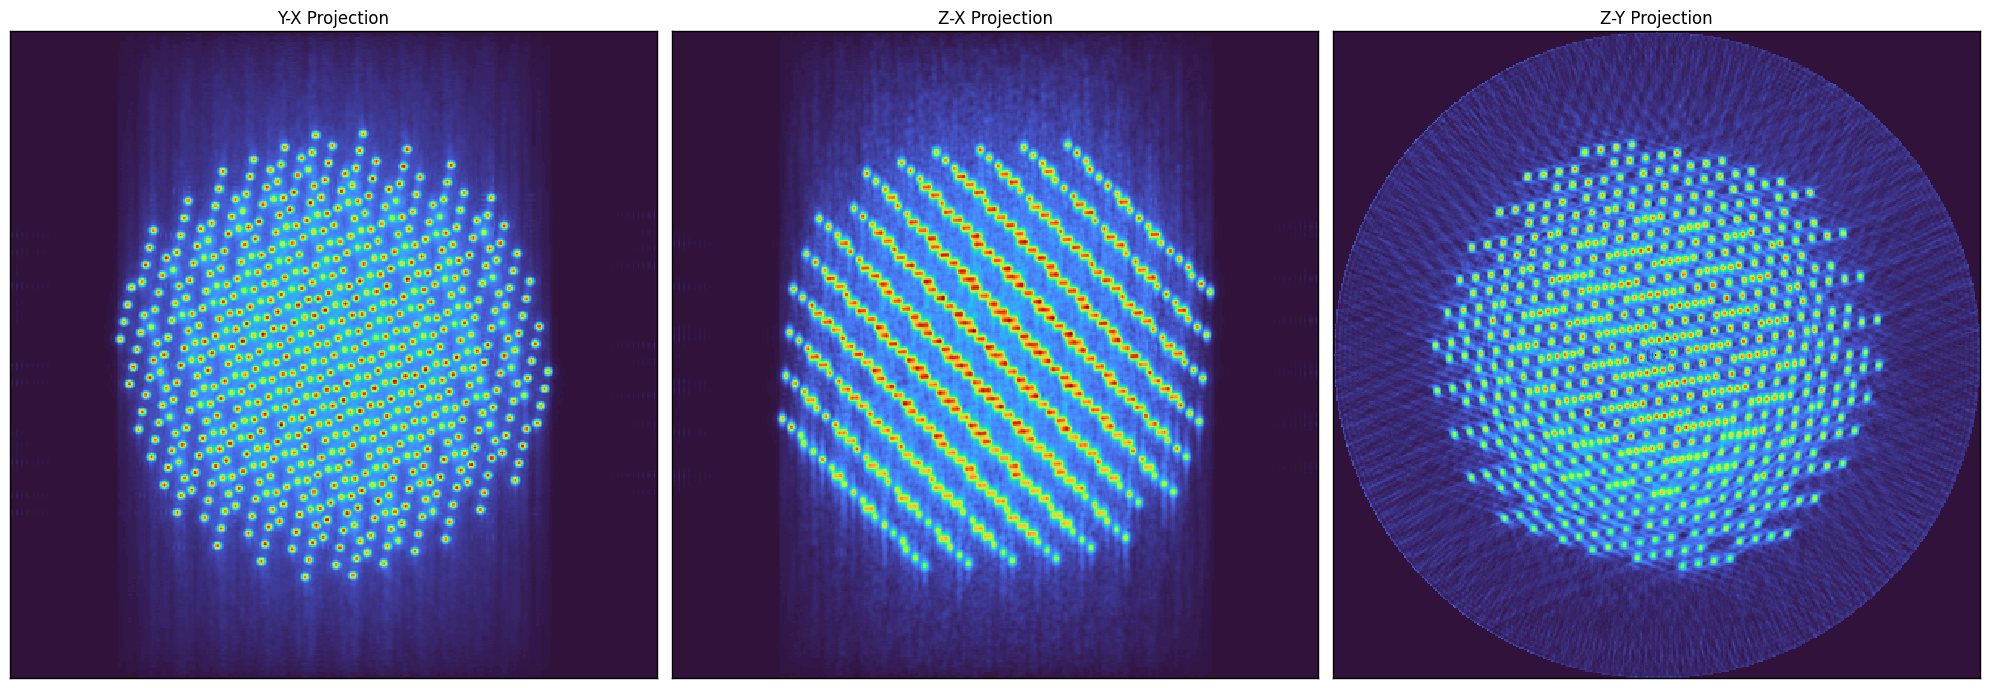

In [8]:
tomo_focused.plot_projections()

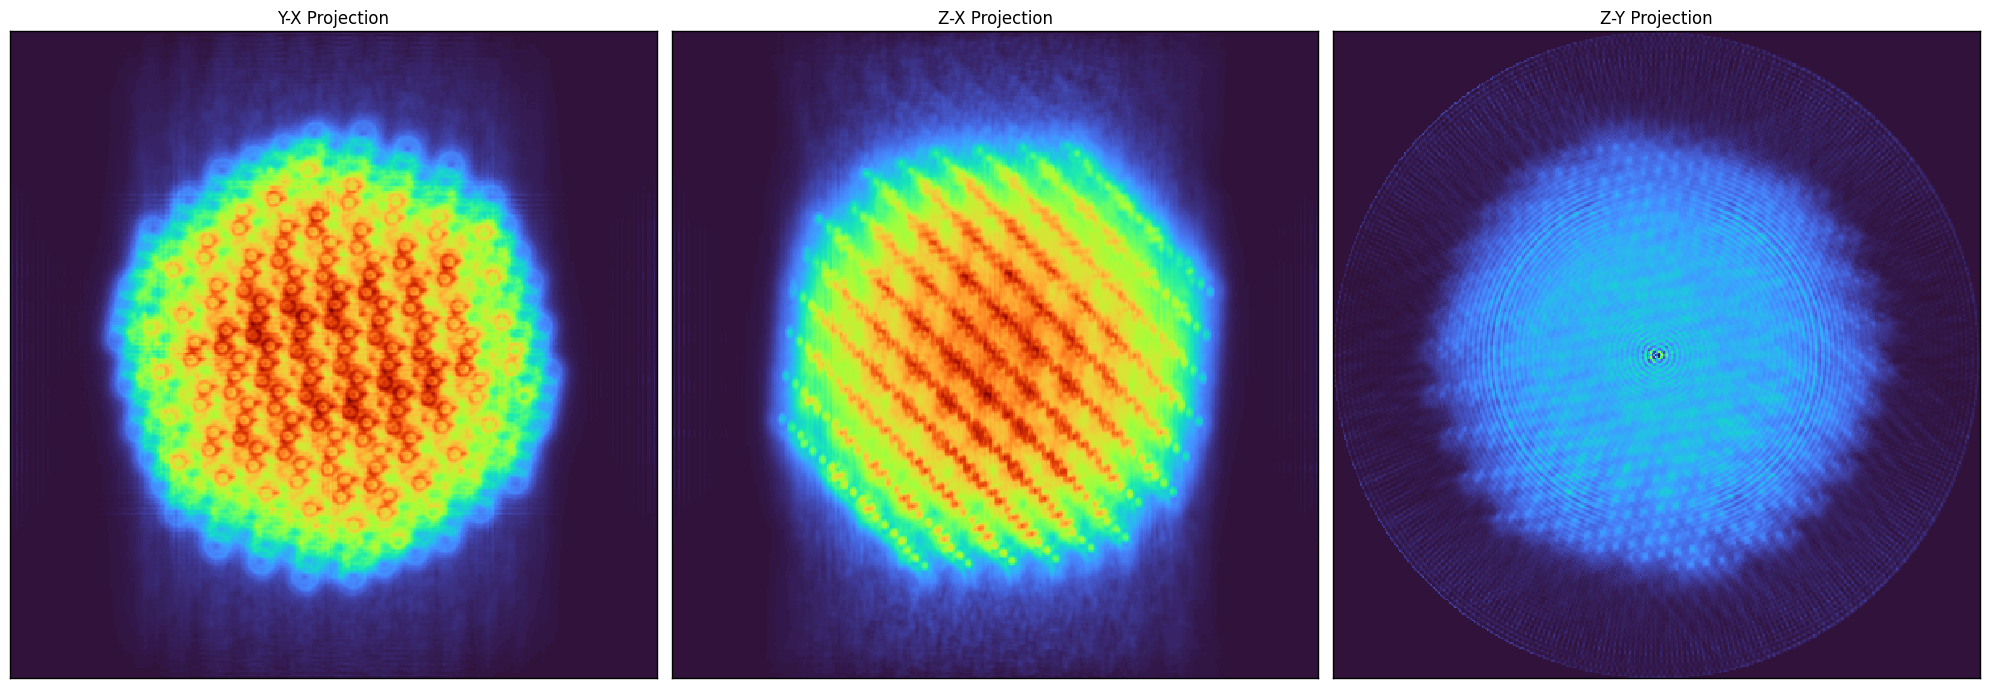

In [9]:
tomo_defocused.plot_projections()

In [10]:
np.save('defocused_recon.npy', tomo_defocused.sirt_recon_vol.obj.detach().cpu().numpy())
np.save('focused_recon.npy', tomo_focused.sirt_recon_vol.obj.detach().cpu().numpy())